<a href="https://colab.research.google.com/github/marcopeduto/marcopeduto/blob/main/AssignementFinal_24_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1 : Ce cours vaut 6 crédits pour moi.

-------

Étudiant : Marco Peduto

Email : marco.peduto@unil.ch

Numéro étudiant : 23415946

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
import statistics

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, recall_score, precision_score, accuracy_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

warnings.filterwarnings('ignore')
%matplotlib inline

# Part 1

In [ ]:
url = "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/Hydroponix.csv"
data_climate = pd.read_csv(url)
data_climate.head()

,Year,Country,Region,Crop_Type,Average_Temperature,Total_Precipitation,CO2_Emissions,Crop_Yield,Irrigation_Access,Pesticide_Use,Fertilizer_Use,Soil_Health_Index,Economic_Impact
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,14.54,10.08,14.78,83.25,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,11.05,33.06,23.25,54.02,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,84.42,27.41,65.53,67.78,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,94.06,14.38,87.58,91.39,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,95.75,44.35,88.08,49.61,401.72


### Exercise 1

In [ ]:
#Question 2

crop_types = data_climate['Crop_Type'].unique()
print(crop_types)

['Corn' 'Wheat' 'Coffee' 'Sugarcane' 'Fruits' 'Rice' 'Barley' 'Vegetables'
 'Soybeans' 'Cotton']


In [ ]:
#Data cleaning

data_climate_filtre = data_climate[data_climate['Crop_Type'].isin(['Rice', 'Wheat'])]
data_climate_filtre = data_climate_filtre.drop(columns=['Region'])
data_groupe = data_climate_filtre.groupby(['Country', 'Year', 'Crop_Type'], as_index=False).mean()
data_groupe['Country'] = data_groupe['Country'].astype('category')
data_groupe['Crop_Type'] = data_groupe['Crop_Type'].astype('category')

data_groupe.head()

,Country,Year,Crop_Type,Average_Temperature,Total_Precipitation,CO2_Emissions,Crop_Yield,Irrigation_Access,Pesticide_Use,Fertilizer_Use,Soil_Health_Index,Economic_Impact
0,Argentina,1990,Rice,25.2500,1540.486667,14.126667,2.686333,58.413333,42.223333,18.710000,72.513333,618.393333
1,Argentina,1990,Wheat,10.7550,867.305000,18.350000,2.686500,39.830000,16.875000,75.195000,75.215000,650.170000
2,Argentina,1991,Rice,14.3175,761.692500,15.115000,2.538000,42.930000,29.302500,59.152500,59.955000,749.937500
3,Argentina,1992,Rice,14.8650,1190.220000,19.710000,2.794500,57.740000,33.495000,54.680000,40.260000,1190.750000
4,Argentina,1992,Wheat,27.5200,1304.713333,20.786667,1.838667,78.210000,30.903333,25.186667,53.616667,581.710000


In [ ]:
#Question 3

nb_countries = data_climate['Country'].nunique()
print(nb_countries)

10


### Exercise 2

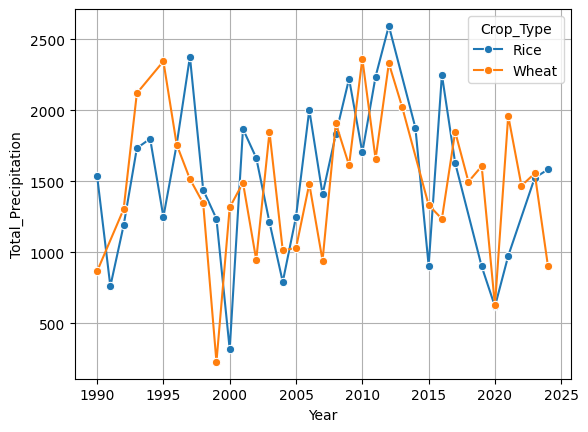

In [ ]:
# Question 4

data_argentine = data_groupe[data_groupe['Country'] == 'Argentina']

sns.lineplot(data=data_argentine, x='Year', y='Total_Precipitation', hue='Crop_Type', marker='o')
plt.grid(True)
plt.show()

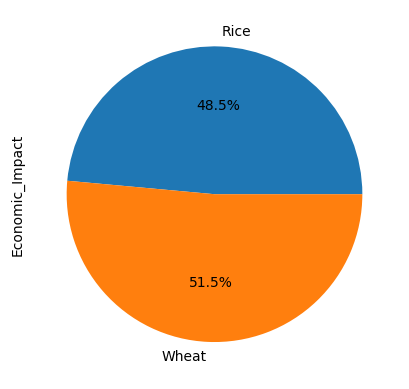

In [ ]:
# Question 5

data_brésil = data_groupe[data_groupe['Country'] == 'Brazil']
impact_eco = data_brésil.groupby('Crop_Type')['Economic_Impact'].sum()
impact_eco.plot.pie(autopct='%1.1f%%')
plt.show()

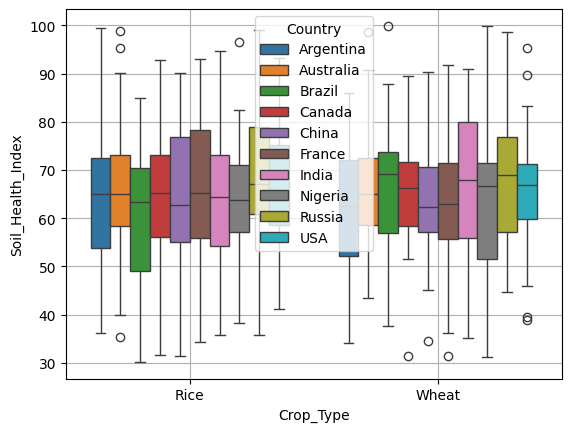

In [ ]:
# Question 6

sns.boxplot(data=data_groupe, x='Crop_Type', y='Soil_Health_Index', hue='Country')
plt.legend
plt.grid(True)
plt.show()

### Exercise 3

In [ ]:
# Question 7 for Wheat

wheat_data = data_climate_filtre[data_climate_filtre['Crop_Type'] == 'Wheat']
x_wheat = wheat_data[['Fertilizer_Use']]
agglocluster_wheat = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
wheat_data['cluster_label'] = agglocluster_wheat.fit_predict(x_wheat)

wheat_cluster_counts = wheat_data['cluster_label'].value_counts()
print(wheat_cluster_counts)

cluster_label
0    348
2    262
1    243
3    194
Name: count, dtype: int64


In [ ]:
# Question 7 for Rice

rice_data = data_groupe[data_groupe['Crop_Type'] == 'Rice']
x_rice = rice_data[['Fertilizer_Use']]
agglocluster_rice = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
rice_data['cluster_label'] = agglocluster_rice.fit_predict(x_rice)

rice_cluster_counts = rice_data['cluster_label'].value_counts()
print(rice_cluster_counts)

cluster_label
0    137
3     85
2     60
1     50
Name: count, dtype: int64


In [ ]:
wheat_data = data_groupe[data_groupe['Crop_Type'] == 'Wheat']
wheat_data_clustering = wheat_data[['Fertilizer_Use']]
agg_clustering_wheat = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
wheat_data['Cluster'] = agg_clustering_wheat.fit_predict(wheat_data_clustering)
wheat_cluster_counts = wheat_data['Cluster'].value_counts()
print(wheat_cluster_counts)

Cluster
0    129
1    126
3     44
2     34
Name: count, dtype: int64


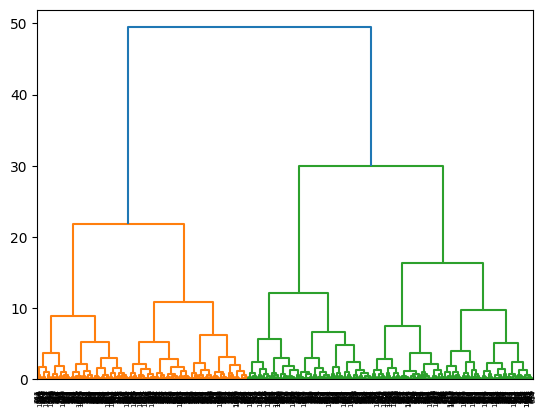

In [ ]:
# Question 8 for Wheat

den_wheat = linkage(x_wheat, method='average', metric='euclidean')
dendrogram(den_wheat)
plt.show()

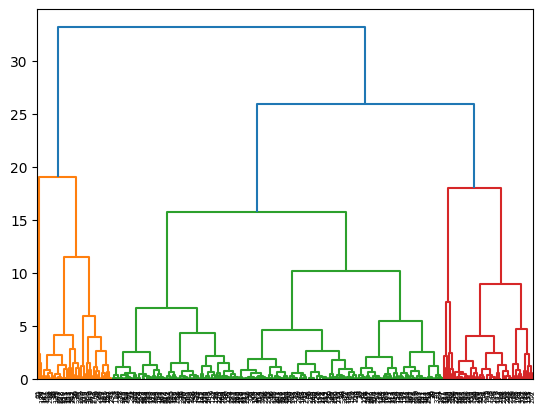

In [ ]:
# Question 8 for Rice

den_rice = linkage(x_rice, method='average', metric='euclidean')
dendrogram(den_rice)
plt.show()

### Exercise 4

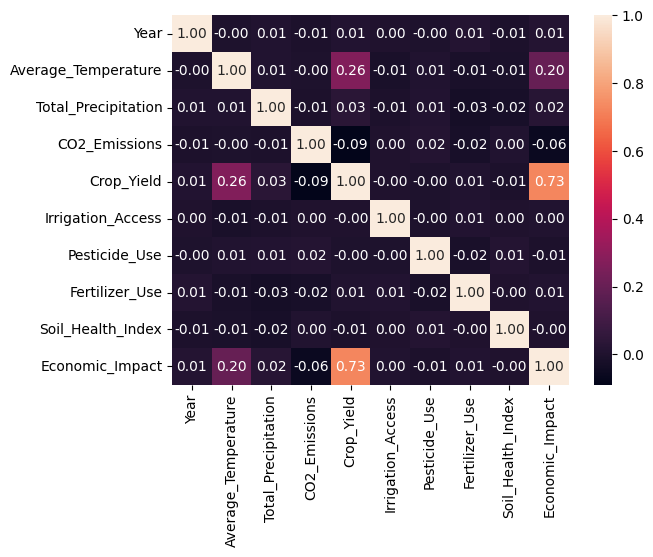

In [ ]:
# Question 9

colonnes = data_climate.select_dtypes(include='number')
sns.heatmap(colonnes.corr(), annot=True, fmt=".2f")
plt.show()

In [ ]:
#Seperate features and labels
data_filtre = data_groupe[data_groupe['Crop_Type'].isin(['Wheat', 'Rice'])]
x = data_filtre[['CO2_Emissions']]
y = data_filtre['Crop_Yield']

# Split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=123, shuffle=True)

# Scale the data
scal = MinMaxScaler()
x_train_scal = scal.fit_transform(x_train)
x_test_scal = scal.transform(x_test)

# Create linear regression model and fit into the training data
modele = LinearRegression()
modele.fit(x_train_scal, y_train)

LinearRegression()

In [ ]:
#Question 10

y_pred = modele.predict(x_test_scal)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2 :", r2)
print("mse :", mse)
print("mae :", mae)

r2 : -0.008411291642242968
mse : 0.4784328793951408
mae : 0.5524848739843548


### Exericise 5

In [ ]:
# Seperate features and labels, and transform the columns Crop_Type and Country (don't forget to delete the old columns)
df = data_groupe.copy()

le = LabelEncoder()
df['Crop_Type_encoded'] = le.fit_transform(df['Crop_Type'])

df = pd.get_dummies(df, columns=['Country'], drop_first=True)

x_multi = df.drop(columns=['Crop_Type', 'Crop_Yield'])
y_multi = df['Crop_Yield']


x_train_m, x_test_m, y_train_m, y_test_m = train_test_split(x_multi, y_multi, test_size=0.3, random_state=123, shuffle=True)


# Split data into train and test sets, create linear regression model and fit into the training data
scal_m = MinMaxScaler()
x_train_m_scal = scal_m.fit_transform(x_train_m)
x_test_m_scal = scal_m.transform(x_test_m)

modele_m = LinearRegression()
modele_m.fit(x_train_m_scal, y_train_m)

LinearRegression()

In [ ]:
#Question 11

y_pred_m = modele_m.predict(x_test_m_scal)
r2_m = r2_score(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
mae_m = mean_absolute_error(y_test_m, y_pred_m)
print("r2 multi :", r2_m)
print("mse multi :", mse_m)
print("mae multi :", mae_m)

r2 multi : 0.5376745556944684
mse multi : 0.21934670443496584
mae multi : 0.37790644466588114


# Part 2

### Exercise 1

In [ ]:
url2 = "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/ml/ratings.csv"
df_ratings = pd.read_csv(url2)
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
# shape of the dataframe
print("Shape of the dataframe :", df_ratings.shape)

# number of ratings available
print("Number of ratings available :", df_ratings.shape[0])

# number of users who provided ratings
print("Number of users who provided ratings:", df_ratings['userId'].nunique())

# number of movies have been rated
print("Number of movies have been rated :", df_ratings['movieId'].nunique())

Shape of the dataframe : (100836, 4)
Number of ratings available : 100836
Number of users who provided ratings: 610
Number of movies have been rated : 9724


### Exercise 2

In [ ]:
#donné

df_ratings_pivot = df_ratings.pivot(index='userId', columns='movieId', values='rating')
df_ratings_pivot.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#donné

df_ratings_pivot.fillna(0, inplace=True)
df_ratings_pivot.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#donné

df_ratings_pivot = df_ratings_pivot.map(lambda x: True if x >= 3 else False)
df_ratings_pivot.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,True,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
frequent_itemsets = apriori(df_ratings_pivot, min_support=0.1, max_len=2, use_colnames=True)

In [ ]:
# Question 12

print("Itemsets nb :", len(frequent_itemsets))

Itemsets nb : 2929


In [ ]:
# Find association rules

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
print(rules)

     antecedents consequents  antecedent support  consequent support  \
0           (32)         (1)            0.280328            0.326230   
1            (1)        (32)            0.326230            0.280328   
2            (1)        (34)            0.326230            0.170492   
3           (34)         (1)            0.170492            0.326230   
4            (1)        (47)            0.326230            0.313115   
...          ...         ...                 ...                 ...   
5345     (60069)     (79132)            0.155738            0.211475   
5346     (79132)     (68157)            0.211475            0.139344   
5347     (68157)     (79132)            0.139344            0.211475   
5348     (68954)     (79132)            0.162295            0.211475   
5349     (79132)     (68954)            0.211475            0.162295   

       support  confidence      lift  representativity  leverage  conviction  \
0     0.150820    0.538012  1.649182               1.0 

In [ ]:
#données

df_movies = pd.read_csv("https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/ml/movies.csv")
def get_movie_name(movie_id):
    return df_movies[df_movies['movieId'] == movie_id]['title'].values[0]

rules['antecedents'] = rules['antecedents'].apply(lambda x: get_movie_name(list(x)[0]))
rules['consequents'] = rules['consequents'].apply(lambda x: get_movie_name(list(x)[0]))

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Toy Story (1995),0.280328,0.326230,0.150820,0.538012,1.649182,1.0,0.059368,1.458415,0.546969,0.330935,0.314324,0.500162
1,Toy Story (1995),Twelve Monkeys (a.k.a. 12 Monkeys) (1995),0.326230,0.280328,0.150820,0.462312,1.649182,1.0,0.059368,1.338456,0.584233,0.330935,0.252870,0.500162
2,Toy Story (1995),Babe (1995),0.326230,0.170492,0.111475,0.341709,2.004252,1.0,0.055856,1.260093,0.743667,0.289362,0.206408,0.497777
3,Babe (1995),Toy Story (1995),0.170492,0.326230,0.111475,0.653846,2.004252,1.0,0.055856,1.946448,0.604046,0.289362,0.486244,0.497777
4,Toy Story (1995),Seven (a.k.a. Se7en) (1995),0.326230,0.313115,0.132787,0.407035,1.299955,1.0,0.030640,1.158391,0.342465,0.262136,0.136734,0.415559


In [ ]:
#Question 13

most_interesting_rule = rules.sort_values(by='lift', ascending=False).iloc[0]
print(most_interesting_rule)

antecedents           Harry Potter and the Prisoner of Azkaban (2004)
consequents            Harry Potter and the Chamber of Secrets (2002)
antecedent support                                           0.142623
consequent support                                           0.142623
support                                                      0.106557
confidence                                                   0.747126
lift                                                         5.238473
representativity                                                  1.0
leverage                                                     0.086216
conviction                                                   3.390537
zhangs_metric                                                0.943698
jaccard                                                       0.59633
certainty                                                    0.705061
kulczynski                                                   0.747126
Name: 5166, dtype: o

In [ ]:
# Question 14

beauty_rules = rules[rules['antecedents'] == 'Beauty and the Beast (1991)']
most_common_with_beauty = beauty_rules.sort_values(by='lift', ascending=False).iloc[0]
print(most_common_with_beauty['consequents'])

Aladdin (1992)


# Part 3

In [ ]:
url3 = "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/refs/heads/master/data/travel.csv"
df_travel = pd.read_csv(url3)

In [ ]:
#first 5 rows

print(df_travel.head())

   Age FrequentFlyer AnnualIncomeClass  ServicesOpted  \
0   36            No     Middle Income              6   
1   34           Yes        Low Income              5   
2   37            No     Middle Income              3   
3   30            No     Middle Income              2   
4   30            No        Low Income              1   

  AccountSyncedToSocialMedia BookedHotelOrNot  Target  
0                         No              Yes       0  
1                        Yes               No       1  
2                        Yes               No       0  
3                         No               No       0  
4                         No               No       0  


In [ ]:
#number of samples in the dataset

print(len(df_travel))

960


In [ ]:
#column types

print(df_travel.dtypes)

Age                            int64
FrequentFlyer                 object
AnnualIncomeClass             object
ServicesOpted                  int64
AccountSyncedToSocialMedia    object
BookedHotelOrNot              object
Target                         int64
dtype: object


### Exercise 1

In [ ]:
# donné

for col in df_travel.select_dtypes(include=['object']).columns:
    df_travel[col] = pd.Categorical(df_travel[col]).codes

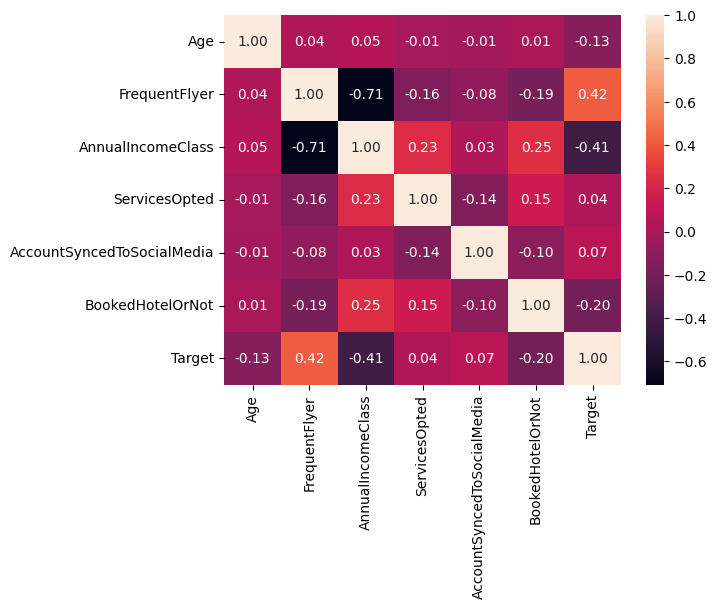

In [ ]:
#Question 15

sns.heatmap(df_travel.corr(), annot=True, fmt=".2f")
plt.show()

In [ ]:
# separate dataset into features and labels

x = df_travel.drop("Target", axis=1)
y = df_travel["Target"]

In [ ]:
# split into train and tests sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#Question 16

precision_base = max(y.value_counts(normalize=True))
print(precision_base)

0.765625


In [ ]:
# Standardise features

standard = StandardScaler()
x_train_scal = standard.fit_transform(x_train)
x_test_scal = standard.transform(x_test)

### Exercise 2

In [ ]:
# Logistic Regression
logreg = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=30)
logreg.fit(x_train_scal, y_train)

y_pred = logreg.predict(x_test_scal)

In [ ]:
# Question 17

test_precision = accuracy_score(y_test, y_pred)
print(test_precision)

0.8541666666666666


In [ ]:
# Logistic with cross-validation

logreg_cross = LogisticRegressionCV(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42, cv=4, Cs=np.logspace(-4, 4, 9), scoring='accuracy')

logreg_cross.fit(x_train_scal, y_train)
y_pred_cross = logreg_cross.predict(x_test_scal)

In [ ]:
# Question 18

reg_paramter = logreg_cross.C_[0]
precision_cross = accuracy_score(y_test, y_pred_cross)

print("regularization parameter :", reg_paramter)
print("precison test : ", precision_cross)

regularization parameter : 1.0
precison test :  0.8541666666666666


### Exercise 3

In [ ]:
#KneighborClassifier

knn = KNeighborsClassifier(n_neighbors=7, p=2, weights='uniform', algorithm="kd_tree")
knn.fit(x_train_scal, y_train)
y_pred_knn = knn.predict(x_test_scal)

precision_knn = accuracy_score(y_test, y_pred_knn)
print(precision_knn)

0.8697916666666666


In [ ]:
#Question 19

param_grid = {"n_neighbors": range(1, 11), "weights": ["uniform", "distance"]}
gs_knn = GridSearchCV(KNeighborsClassifier(algorithm="kd_tree"), param_grid, cv=5)
gs_knn.fit(x_train_scal, y_train)
best_knn = gs_knn.best_estimator_
y_pred_best_knn = best_knn.predict(x_test_scal)
test_precision_best_knn = accuracy_score(y_test, y_pred_best_knn)
print(test_precision_best_knn)


0.8697916666666666


In [ ]:
#Question 20

best_knn = gs_knn.best_params_
print(best_knn)

{'n_neighbors': 3, 'weights': 'distance'}


### Exercise 4

In [ ]:
#Decision Tree

tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=30)
tree.fit(x_train, y_train)

y_pred_tree = tree.predict(x_test)
precision_tree = accuracy_score(y_test, y_pred_tree)
print(precision_tree)

0.8541666666666666


In [ ]:
#Question 21

param_grid = {"max_depth": range(1, 8), "criterion": ["gini", "entropy"]}
grid_search_tree = GridSearchCV(DecisionTreeClassifier(random_state=30), param_grid, cv=5)
grid_search_tree.fit(x_train, y_train)
best_tree = grid_search_tree.best_estimator_
y_pred_best_tree = best_tree.predict(x_test)
precision_best_tree = accuracy_score(y_test, y_pred_best_tree)

print(precision_best_tree)

0.8958333333333334


In [ ]:
#Question 22

print(grid_search_tree.best_params_)

{'criterion': 'gini', 'max_depth': 6}


In [ ]:
#question 23

recall_best_tree = recall_score(y_test, y_pred_best_tree)
print(recall_best_tree)

0.6444444444444445


In [ ]:
#comparaison

recall_best_logreg = recall_score(y_test, y_pred_cross)
print(recall_best_logreg)

recall_best_knn = recall_score(y_test, y_pred_best_knn)
print(recall_best_knn)

print(recall_best_tree)

0.4888888888888889
0.5777777777777777
0.6444444444444445


In [ ]:
#question 24
recalls = {"Logistic Regression": recall_best_logreg, "KNN": recall_best_knn, "Decision Tree": recall_best_tree}

best_model = max(recalls, key=recalls.get)
print(best_model)

Decision Tree
